In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as spd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


# Data

In [2]:

# -------------------------
# Project paths
# -------------------------
zarr_file = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"

reference_dir = Path("/coh_labs/yunroseli/Jona/CAR-T/data/references")
pathway_dir = reference_dir / "pathways"
select_pathway_dir = reference_dir / "select_pathways"

# outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis")
# outdir.mkdir(parents=True, exist_ok=True)
outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm")
outdir.mkdir(parents=True, exist_ok=True)

print(f"Pathway dir exists: {pathway_dir.exists()}")
print(f"Output dir: {outdir}")


sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]

Pathway dir exists: True
Output dir: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_spatial_analysis_lognorm


## Normalization

In [3]:
# Normalize raw counts before pathway scoring and marker summaries
# This modifies only the in-memory AnnData unless you explicitly write it back.
if "counts" not in adata.layers:
    adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
    inplace=True
)

sc.pp.log1p(adata)

adata.uns["pathway_score_normalization"] = {
    "method": "scanpy.pp.normalize_total followed by scanpy.pp.log1p",
    "target_sum": 1e4,
    "use_raw": False,
}

print("Normalized adata.X with normalize_total(target_sum=1e4) + log1p.")

Normalized adata.X with normalize_total(target_sum=1e4) + log1p.


# Loading GMT files

In [4]:
gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp": pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
}

for name, path in gmt_files.items():
    print(name, path, path.exists())

hallmark /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/mh.all.v2026.1.Mm.symbols.gmt True
reactome /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.reactome.v2026.1.Mm.symbols.gmt True
go_bp /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m5.go.bp.v2026.1.Mm.symbols.gmt True


In [5]:
def read_gmt(gmt_path):
    gene_sets = {}
    rows = []

    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue

            gene_set = parts[0]
            description = parts[1]
            genes = parts[2:]

            gene_sets[gene_set] = genes
            rows.append({
                "gene_set": gene_set,
                "description": description,
                "n_genes": len(genes),
                "source_file": Path(gmt_path).name
            })

    return gene_sets, pd.DataFrame(rows)


all_gene_sets = {}
gene_set_metadata_list = []

for collection, path in gmt_files.items():
    gs, meta = read_gmt(path)
    meta["collection"] = collection

    all_gene_sets.update(gs)
    gene_set_metadata_list.append(meta)

gene_set_metadata = pd.concat(gene_set_metadata_list, ignore_index=True)

print(f"Total gene sets loaded: {len(all_gene_sets):,}")
display(gene_set_metadata.head())

Total gene sets loaded: 9,164


,gene_set,description,n_genes,source_file,collection
0,HALLMARK_ADIPOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,200,mh.all.v2026.1.Mm.symbols.gmt,hallmark
1,HALLMARK_ALLOGRAFT_REJECTION,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,192,mh.all.v2026.1.Mm.symbols.gmt,hallmark
2,HALLMARK_ANDROGEN_RESPONSE,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,96,mh.all.v2026.1.Mm.symbols.gmt,hallmark
3,HALLMARK_ANGIOGENESIS,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,36,mh.all.v2026.1.Mm.symbols.gmt,hallmark
4,HALLMARK_APICAL_JUNCTION,https://www.gsea-msigdb.org/gsea/msigdb/mouse/...,199,mh.all.v2026.1.Mm.symbols.gmt,hallmark


# NK Cells

In [7]:
celltype_col = "c2l_permissive"

lymphocyte_types = [
    "CD8_T",
    "CD4_T",
    "Treg",
    "NK",
    "NKT",
    "B",
]

cytotoxic_lymphocyte_types = [
    "CD8_T",
    "NK",
    "NKT",
]

nk_types = ["NK"]

focus_treatments = [
    "CyPSCA_Tu1",
    "CyPSCA_Tu2",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
    "CyT72_Tu1",
    "RTCyT72_Tu1",
    "NoTx_Tu1",
]

adata.obs["is_lymphocyte"] = adata.obs[celltype_col].astype(str).isin(lymphocyte_types)
adata.obs["is_cytotoxic_lymphocyte"] = adata.obs[celltype_col].astype(str).isin(cytotoxic_lymphocyte_types)
adata.obs["is_nk"] = adata.obs[celltype_col].astype(str).eq("NK")

print("Lymphocyte labels included:")
print(lymphocyte_types)

print("Counts:")
print(adata.obs[["is_lymphocyte", "is_cytotoxic_lymphocyte", "is_nk"]].sum())

Lymphocyte labels included:
['CD8_T', 'CD4_T', 'Treg', 'NK', 'NKT', 'B']
Counts:
is_lymphocyte              131520
is_cytotoxic_lymphocyte     75858
is_nk                       22924
dtype: int64


In [8]:
marker_genes = [
    "Gzmb", "Gzma", "Prf1", "Nkg7", "Ccl5", "Ifng",
    "Klrd1", "Klrk1", "Ncr1", "Fasl"
]

marker_genes = [g for g in marker_genes if g in adata.var_names]

print("Marker genes found:")
print(marker_genes)

marker_expr = adata[:, marker_genes].to_df()

for gene in marker_genes:
    adata.obs[f"{gene}_expr"] = marker_expr[gene].values

Marker genes found:
['Gzmb', 'Gzma', 'Prf1', 'Nkg7', 'Ccl5', 'Ifng', 'Klrd1', 'Klrk1', 'Ncr1', 'Fasl']


In [9]:
nk_mask_global = adata.obs["is_nk"]

for gene in ["Gzmb", "Prf1", "Nkg7", "Ccl5"]:
    expr_col = f"{gene}_expr"
    if expr_col not in adata.obs.columns:
        continue

    q75 = adata.obs.loc[nk_mask_global, expr_col].quantile(0.75)
    q90 = adata.obs.loc[nk_mask_global, expr_col].quantile(0.90)

    adata.obs[f"NK_{gene}_high_q75"] = adata.obs["is_nk"] & (adata.obs[expr_col] >= q75)
    adata.obs[f"NK_{gene}_high_q90"] = adata.obs["is_nk"] & (adata.obs[expr_col] >= q90)

    print(f"{gene}")
    print(f"  NK q75 threshold: {q75:.4f}")
    print(f"  NK q90 threshold: {q90:.4f}")

Gzmb
  NK q75 threshold: 1.7431
  NK q90 threshold: 2.9609
Prf1
  NK q75 threshold: 0.0000
  NK q90 threshold: 2.5359
Nkg7
  NK q75 threshold: 0.0000
  NK q90 threshold: 1.0930
Ccl5
  NK q75 threshold: 0.0000
  NK q90 threshold: 1.2430


In [10]:
nk_composition_summary = (
    adata.obs
    .loc[adata.obs["treatment"].isin(focus_treatments)]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_total_cells=("tissue", "size"),
        n_lymphocytes=("is_lymphocyte", "sum"),
        n_cytotoxic_lymphocytes=("is_cytotoxic_lymphocyte", "sum"),
        n_nk=("is_nk", "sum"),
    )
    .reset_index()
)

nk_composition_summary["frac_nk_of_lymphocytes"] = (
    nk_composition_summary["n_nk"] / nk_composition_summary["n_lymphocytes"]
)

nk_composition_summary["frac_cytotoxic_of_lymphocytes"] = (
    nk_composition_summary["n_cytotoxic_lymphocytes"] / nk_composition_summary["n_lymphocytes"]
)

display(nk_composition_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_total_cells,n_lymphocytes,n_cytotoxic_lymphocytes,n_nk,frac_nk_of_lymphocytes,frac_cytotoxic_of_lymphocytes
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,12497,8664,2400,0.192046,0.693286
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,55540,4704,2452,722,0.153486,0.521259
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,33085,927,524,247,0.266451,0.565264
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,27025,2328,1234,252,0.108247,0.530069
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,86108,1305,794,266,0.203831,0.608429
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,61384,608,200,61,0.100329,0.328947
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,67945,227,32,3,0.013216,0.140969
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,54121,14185,12347,2671,0.188297,0.870427
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,34108,731,383,154,0.210670,0.523940
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,49785,1968,987,340,0.172764,0.501524


In [11]:
nk_activation_summary = (
    adata.obs
    .loc[
        adata.obs["treatment"].isin(focus_treatments)
        & adata.obs["is_nk"]
    ]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_nk=("is_nk", "size"),
        mean_Gzmb=("Gzmb_expr", "mean"),
        median_Gzmb=("Gzmb_expr", "median"),
        mean_Prf1=("Prf1_expr", "mean") if "Prf1_expr" in adata.obs.columns else ("is_nk", "size"),
        mean_Nkg7=("Nkg7_expr", "mean") if "Nkg7_expr" in adata.obs.columns else ("is_nk", "size"),
        mean_Ccl5=("Ccl5_expr", "mean") if "Ccl5_expr" in adata.obs.columns else ("is_nk", "size"),
        frac_NK_Gzmb_high_q75=("NK_Gzmb_high_q75", "mean"),
        frac_NK_Gzmb_high_q90=("NK_Gzmb_high_q90", "mean"),
    )
    .reset_index()
)

display(nk_activation_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,mean_Gzmb,median_Gzmb,mean_Prf1,mean_Nkg7,mean_Ccl5,frac_NK_Gzmb_high_q75,frac_NK_Gzmb_high_q90
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.465761,0.000000,0.292344,0.071220,0.166972,0.167500,0.051667
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,1.315295,0.000000,0.955207,0.338611,0.460537,0.441828,0.191136
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,2.165560,2.456248,1.680344,0.515659,1.067305,0.716599,0.364372
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,1.035405,0.000000,0.742958,0.211992,0.306611,0.365079,0.095238
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,266,1.555519,2.016866,1.327879,0.503063,0.736700,0.530075,0.221805
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,61,1.737917,2.135667,1.086568,0.692529,0.660513,0.606557,0.245902
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,3,0.945410,0.000000,1.626644,0.765943,0.860702,0.333333,0.000000
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,2671,1.454416,1.687737,1.178883,0.533363,0.623468,0.486709,0.139274
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,1.684386,0.000000,1.367346,0.403488,0.293088,0.487013,0.376623
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,1.640304,2.038627,1.196521,0.478673,0.390812,0.558824,0.235294


In [12]:
nk_high_lymphocyte_summary = (
    adata.obs
    .loc[adata.obs["treatment"].isin(focus_treatments)]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_lymphocytes=("is_lymphocyte", "sum"),
        n_nk=("is_nk", "sum"),
        n_NK_Gzmb_high_q75=("NK_Gzmb_high_q75", "sum"),
        n_NK_Gzmb_high_q90=("NK_Gzmb_high_q90", "sum"),
    )
    .reset_index()
)

nk_high_lymphocyte_summary["frac_NK_Gzmb_high_q75_of_lymphocytes"] = (
    nk_high_lymphocyte_summary["n_NK_Gzmb_high_q75"] /
    nk_high_lymphocyte_summary["n_lymphocytes"]
)

nk_high_lymphocyte_summary["frac_NK_Gzmb_high_q90_of_lymphocytes"] = (
    nk_high_lymphocyte_summary["n_NK_Gzmb_high_q90"] /
    nk_high_lymphocyte_summary["n_lymphocytes"]
)

display(nk_high_lymphocyte_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_lymphocytes,n_nk,n_NK_Gzmb_high_q75,n_NK_Gzmb_high_q90,frac_NK_Gzmb_high_q75_of_lymphocytes,frac_NK_Gzmb_high_q90_of_lymphocytes
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,12497,2400,402,124,0.032168,0.009922
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,4704,722,319,138,0.067815,0.029337
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,927,247,177,90,0.190939,0.097087
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,2328,252,92,24,0.039519,0.010309
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,1305,266,141,59,0.108046,0.045211
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,608,61,37,15,0.060855,0.024671
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,227,3,1,0,0.004405,0.000000
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,14185,2671,1300,372,0.091646,0.026225
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,731,154,75,58,0.102599,0.079343
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,1968,340,190,80,0.096545,0.040650


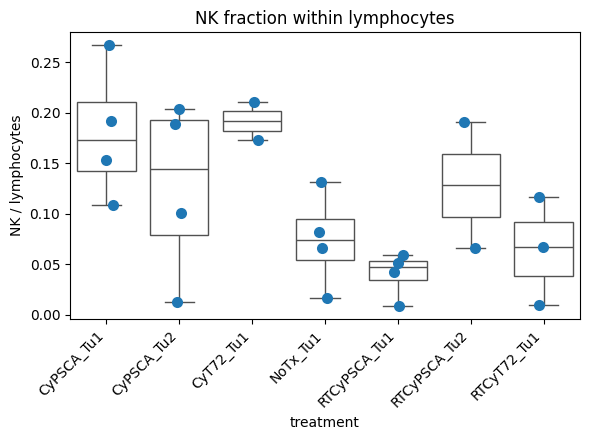

In [13]:
plot_df = nk_composition_summary.copy()

plt.figure(figsize=(6, 4.5))
sns.stripplot(
    data=plot_df,
    x="treatment",
    y="frac_nk_of_lymphocytes",
    size=8,
    jitter=True
)
sns.boxplot(
    data=plot_df,
    x="treatment",
    y="frac_nk_of_lymphocytes",
    showfliers=False,
    boxprops={"facecolor": "none"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("NK / lymphocytes")
plt.title("NK fraction within lymphocytes")
plt.tight_layout()
plt.show()

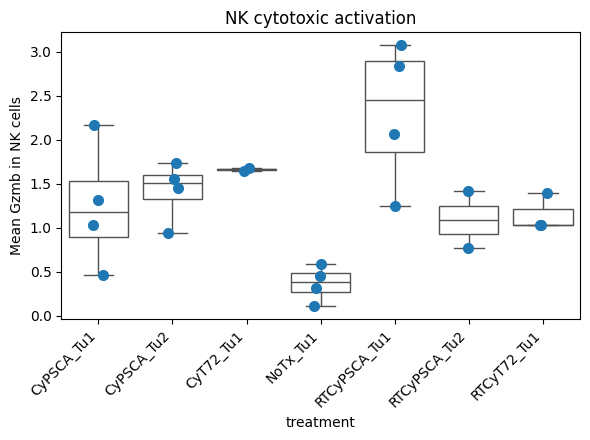

In [14]:
plot_df = nk_activation_summary.copy()

plt.figure(figsize=(6, 4.5))
sns.stripplot(
    data=plot_df,
    x="treatment",
    y="mean_Gzmb",
    size=8,
    jitter=True
)
sns.boxplot(
    data=plot_df,
    x="treatment",
    y="mean_Gzmb",
    showfliers=False,
    boxprops={"facecolor": "none"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean Gzmb in NK cells")
plt.title("NK cytotoxic activation")
plt.tight_layout()
plt.show()

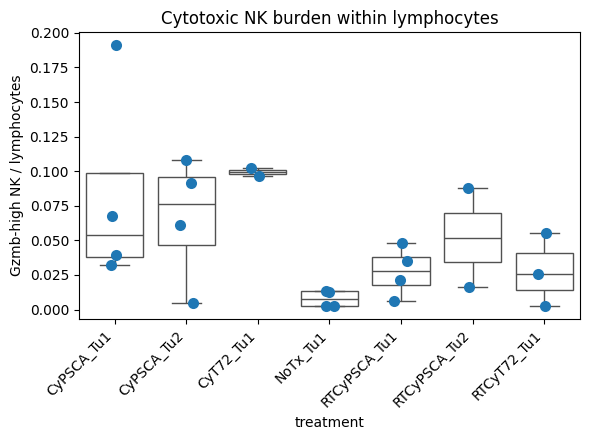

In [15]:
plot_df = nk_high_lymphocyte_summary.copy()

plt.figure(figsize=(6, 4.5))
sns.stripplot(
    data=plot_df,
    x="treatment",
    y="frac_NK_Gzmb_high_q75_of_lymphocytes",
    size=8,
    jitter=True
)
sns.boxplot(
    data=plot_df,
    x="treatment",
    y="frac_NK_Gzmb_high_q75_of_lymphocytes",
    showfliers=False,
    boxprops={"facecolor": "none"}
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Gzmb-high NK / lymphocytes")
plt.title("Cytotoxic NK burden within lymphocytes")
plt.tight_layout()
plt.show()

## NK Statistics

In [16]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def cliffs_delta_b_vs_a(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    greater = 0
    less = 0

    for bi in b:
        greater += np.sum(bi > a)
        less += np.sum(bi < a)

    return (greater - less) / (len(a) * len(b))


def compare_metric(df, metric, group_a="CyPSCA_Tu1", group_b="RTCyPSCA_Tu1"):
    a = df.loc[df["treatment"].eq(group_a), metric].dropna()
    b = df.loc[df["treatment"].eq(group_b), metric].dropna()

    if len(a) >= 2 and len(b) >= 2:
        stat, p = mannwhitneyu(a, b, alternative="two-sided")
        delta = cliffs_delta_b_vs_a(a, b)
    else:
        p = np.nan
        delta = np.nan

    return {
        "metric": metric,
        "group_a": group_a,
        "group_b": group_b,
        "n_group_a": len(a),
        "n_group_b": len(b),
        "mean_group_a": a.mean(),
        "mean_group_b": b.mean(),
        "difference_b_minus_a": b.mean() - a.mean(),
        "cliffs_delta_b_vs_a": delta,
        "mannwhitney_p": p,
    }

In [17]:
nk_stat_rows = []

nk_stat_rows.append(
    compare_metric(nk_composition_summary, "frac_nk_of_lymphocytes")
)

nk_stat_rows.append(
    compare_metric(nk_composition_summary, "frac_cytotoxic_of_lymphocytes")
)

nk_stat_rows.append(
    compare_metric(nk_activation_summary, "mean_Gzmb")
)

nk_stat_rows.append(
    compare_metric(nk_activation_summary, "frac_NK_Gzmb_high_q75")
)

nk_stat_rows.append(
    compare_metric(nk_high_lymphocyte_summary, "frac_NK_Gzmb_high_q75_of_lymphocytes")
)

nk_stats_df = pd.DataFrame(nk_stat_rows)

display(nk_stats_df)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p
0,frac_nk_of_lymphocytes,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.180058,0.040720,-0.139338,-1.000,0.028571
1,frac_cytotoxic_of_lymphocytes,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.577469,0.212983,-0.364487,-1.000,0.028571
2,mean_Gzmb,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,1.245506,2.303795,1.058290,0.625,0.200000
3,frac_NK_Gzmb_high_q75,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.422752,0.685747,0.262995,0.625,0.200000
4,frac_NK_Gzmb_high_q75_of_lymphocytes,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.082610,0.027702,-0.054908,-0.625,0.200000


# Cytotoxicity

In [18]:
nk_curated_pathway_panel = {
    "GranzymeDeath_GO": "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY",
    "NK_MediatedImmunity_GO": "GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY",
    "NK_Degranulation_GO": "GOBP_NATURAL_KILLER_CELL_DEGRANULATION",
    "LeukocyteCytotoxicity_GO": "GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY",
}

nk_panel_check = []

for short_name, gene_set_name in nk_curated_pathway_panel.items():
    nk_panel_check.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "found": gene_set_name in all_gene_sets,
        "n_genes": len(all_gene_sets[gene_set_name]) if gene_set_name in all_gene_sets else np.nan,
        "source_file": gene_set_metadata.loc[
            gene_set_metadata["gene_set"].eq(gene_set_name),
            "source_file"
        ].iloc[0] if gene_set_name in all_gene_sets else np.nan
    })

nk_panel_check_df = pd.DataFrame(nk_panel_check)
display(nk_panel_check_df)

,short_name,gene_set_name,found,n_genes,source_file
0,GranzymeDeath_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,True,11,m5.go.bp.v2026.1.Mm.symbols.gmt
1,NK_MediatedImmunity_GO,GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY,True,99,m5.go.bp.v2026.1.Mm.symbols.gmt
2,NK_Degranulation_GO,GOBP_NATURAL_KILLER_CELL_DEGRANULATION,True,11,m5.go.bp.v2026.1.Mm.symbols.gmt
3,LeukocyteCytotoxicity_GO,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,True,181,m5.go.bp.v2026.1.Mm.symbols.gmt


In [19]:
for short_name, gene_set_name in nk_curated_pathway_panel.items():
    genes = all_gene_sets[gene_set_name]
    genes_present = [g for g in genes if g in adata.var_names]
    genes_missing = [g for g in genes if g not in adata.var_names]

    print("\n" + short_name)
    print(gene_set_name)
    print(f"Total genes in pathway: {len(genes)}")
    print(f"Genes present in adata: {len(genes_present)}")
    print(f"Genes missing from adata: {len(genes_missing)}")
    print("Present genes:")
    print(genes_present)


GranzymeDeath_GO
GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY
Total genes in pathway: 11
Genes present in adata: 10
Genes missing from adata: 1
Present genes:
['Bnip3', 'Gzma', 'Gzmb', 'Gzmc', 'Gzmk', 'Lamp1', 'Nkg7', 'Prf1', 'Srgn', 'Ube4b']

NK_MediatedImmunity_GO
GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY
Total genes in pathway: 99
Genes present in adata: 98
Genes missing from adata: 1
Present genes:
['Ap1g1', 'Arl8b', 'Arrb2', 'Bid', 'Cadm1', 'Calhm6', 'Cd160', 'Cd2', 'Cd226', 'Cd96', 'Ceacam1', 'Cebpg', 'Clec12b', 'Clec2d', 'Clnk', 'Coro1a', 'Crk', 'Crtam', 'Dpp4', 'Fcgr4', 'Gfer', 'Gimap3', 'Gimap5', 'Grb2', 'Gzmb', 'Gzmc', 'H2-M3', 'H60b', 'H60c', 'Havcr2', 'Hcst', 'Igf2', 'Il12a', 'Il12b', 'Il18', 'Il18rap', 'Il21', 'Inpp5d', 'Kctd9', 'Kif5b', 'Klrb1', 'Klrb1a', 'Klrb1b', 'Klrb1c', 'Klrb1f', 'Klrc1', 'Klrc3', 'Klrd1', 'Klre1', 'Klri1', 'Klri2', 'Klrk1', 'Lag3', 'Lamp1', 'Lep', 'Lgals9', 'Lyst', 'Nectin2', 'Nectin4', 'Nfkbiz', 'Nkg7', 'Pik3c3', 'Pik3cb', 'Pik3

In [20]:
available_genes = set(adata.var_names.astype(str))

nk_score_records = []

for short_name, gene_set_name in nk_curated_pathway_panel.items():
    pathway_genes = all_gene_sets[gene_set_name]

    matched_genes = [g for g in pathway_genes if g in available_genes]
    missing_genes = [g for g in pathway_genes if g not in available_genes]

    score_col = f"{short_name}_score"

    print(f"\nScoring: {short_name}")
    print(f"  MSigDB pathway: {gene_set_name}")
    print(f"  pathway genes: {len(pathway_genes)}")
    print(f"  matched genes: {len(matched_genes)}")
    print(f"  missing genes: {len(missing_genes)}")

    if len(matched_genes) < 5:
        print(f"  WARNING: fewer than 5 matched genes. Skipping {short_name}.")
        continue

    sc.tl.score_genes(
        adata,
        gene_list=matched_genes,
        score_name=score_col,
        use_raw=False
    )

    nk_score_records.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "score_col": score_col,
        "n_pathway_genes": len(pathway_genes),
        "n_matched_genes": len(matched_genes),
        "n_missing_genes": len(missing_genes),
        "matched_genes": ";".join(matched_genes),
        "missing_genes": ";".join(missing_genes),
    })

nk_score_summary_df = pd.DataFrame(nk_score_records)
display(nk_score_summary_df)

nk_score_summary_df.to_csv(
    outdir / "nk_curated_cytotoxic_pathway_score_gene_matching_summary.csv",
    index=False
)


Scoring: GranzymeDeath_GO
  MSigDB pathway: GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY
  pathway genes: 11
  matched genes: 10
  missing genes: 1

Scoring: NK_MediatedImmunity_GO
  MSigDB pathway: GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY
  pathway genes: 99
  matched genes: 98
  missing genes: 1

Scoring: NK_Degranulation_GO
  MSigDB pathway: GOBP_NATURAL_KILLER_CELL_DEGRANULATION
  pathway genes: 11
  matched genes: 11
  missing genes: 0

Scoring: LeukocyteCytotoxicity_GO
  MSigDB pathway: GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY
  pathway genes: 181
  matched genes: 167
  missing genes: 14


,short_name,gene_set_name,score_col,n_pathway_genes,n_matched_genes,n_missing_genes,matched_genes,missing_genes
0,GranzymeDeath_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,GranzymeDeath_GO_score,11,10,1,Bnip3;Gzma;Gzmb;Gzmc;Gzmk;Lamp1;Nkg7;Prf1;Srgn...,Gsdme
1,NK_MediatedImmunity_GO,GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY,NK_MediatedImmunity_GO_score,99,98,1,Ap1g1;Arl8b;Arrb2;Bid;Cadm1;Calhm6;Cd160;Cd2;C...,Klrc2
2,NK_Degranulation_GO,GOBP_NATURAL_KILLER_CELL_DEGRANULATION,NK_Degranulation_GO_score,11,11,0,Ap1g1;Cd160;Coro1a;Fcgr4;Kctd9;Lamp1;Lgals9;Nk...,
3,LeukocyteCytotoxicity_GO,GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY,LeukocyteCytotoxicity_GO_score,181,167,14,Ager;Ap1g1;Arg1;Arl8b;Arrb2;Azgp1;B2m;Bid;Cadm...,2410137M14Rik;Cd1d2;Cx3cr1;Cyrib;Gfus;H2-Ea;H2...


In [21]:
nk_score_cols = nk_score_summary_df["score_col"].tolist()

nk_pathway_summary = (
    adata.obs
    .loc[
        adata.obs["c2l_permissive"].astype(str).eq("NK")
        & adata.obs["treatment"].isin([
            "CyPSCA_Tu1",
            "CyPSCA_Tu2",
            "RTCyPSCA_Tu1",
            "RTCyPSCA_Tu2",
            "CyT72_Tu1",
            "RTCyT72_Tu1",
            "NoTx_Tu1",
        ])
    ]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_nk=("c2l_permissive", "size"),
        **{f"{score_col}_mean": (score_col, "mean") for score_col in nk_score_cols},
        **{f"{score_col}_median": (score_col, "median") for score_col in nk_score_cols}
    )
    .reset_index()
)

display(nk_pathway_summary)

nk_pathway_summary.to_csv(
    outdir / "nk_cell_curated_cytotoxic_pathway_summary.csv",
    index=False
)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,GranzymeDeath_GO_score_mean,NK_MediatedImmunity_GO_score_mean,NK_Degranulation_GO_score_mean,LeukocyteCytotoxicity_GO_score_mean,GranzymeDeath_GO_score_median,NK_MediatedImmunity_GO_score_median,NK_Degranulation_GO_score_median,LeukocyteCytotoxicity_GO_score_median
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.131324,0.006018,-0.025377,0.019263,0.059944,-0.003610,-0.076602,0.012648
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,0.512101,0.094522,0.123287,0.102794,0.503609,0.088913,0.093432,0.098407
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,0.867393,0.197189,0.268339,0.205517,0.909168,0.196676,0.273653,0.209500
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,0.392048,0.051551,0.041583,0.075393,0.371186,0.047348,0.008159,0.069089
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,266,0.703352,0.155180,0.218598,0.161350,0.660890,0.153517,0.206368,0.163997
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,61,0.749445,0.155577,0.219631,0.179175,0.726829,0.150042,0.254235,0.173448
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,3,0.775263,0.133856,0.021954,0.174548,0.765258,0.140862,0.123384,0.160689
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,2671,0.607594,0.136670,0.197401,0.150487,0.624611,0.141815,0.178933,0.155953
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,0.787822,0.121001,0.096436,0.109364,0.794656,0.117704,0.092340,0.115429
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,0.700754,0.127281,0.139309,0.131841,0.681557,0.126503,0.107353,0.131190


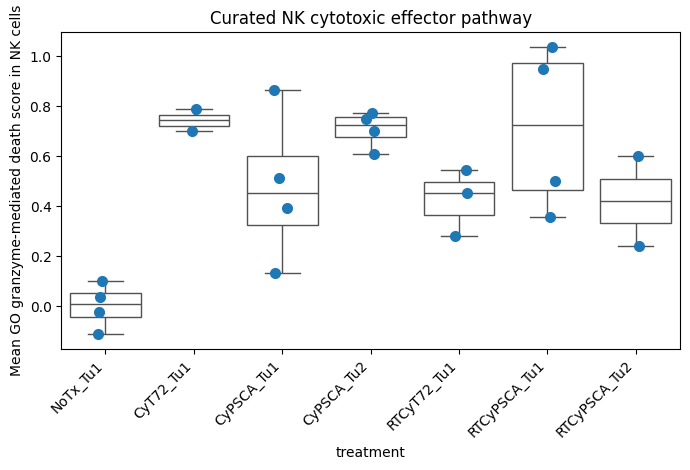

In [22]:
plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "CyPSCA_Tu2",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

metric = "GranzymeDeath_GO_score_mean"

plt.figure(figsize=(7, 4.8))

sns.stripplot(
    data=nk_pathway_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    size=8,
    jitter=True
)

sns.boxplot(
    data=nk_pathway_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean GO granzyme-mediated death score in NK cells")
plt.title("Curated NK cytotoxic effector pathway")
plt.tight_layout()
plt.show()

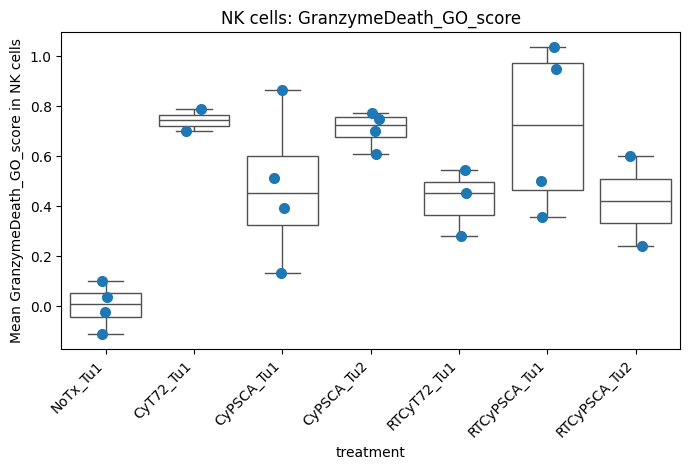

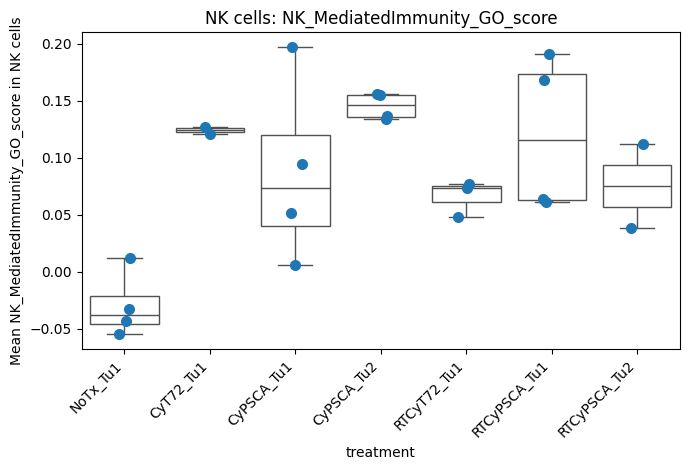

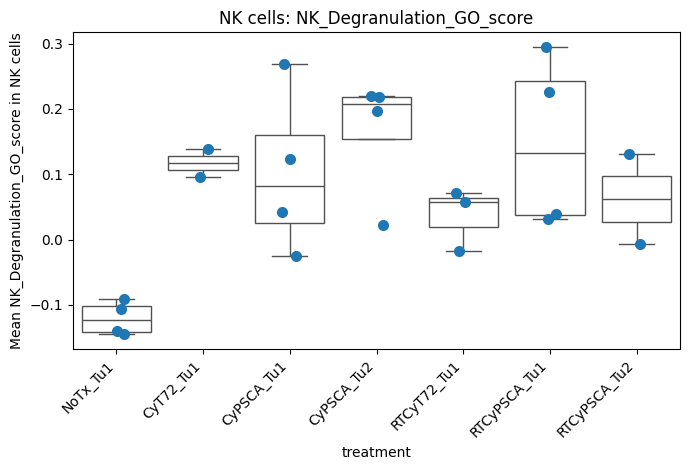

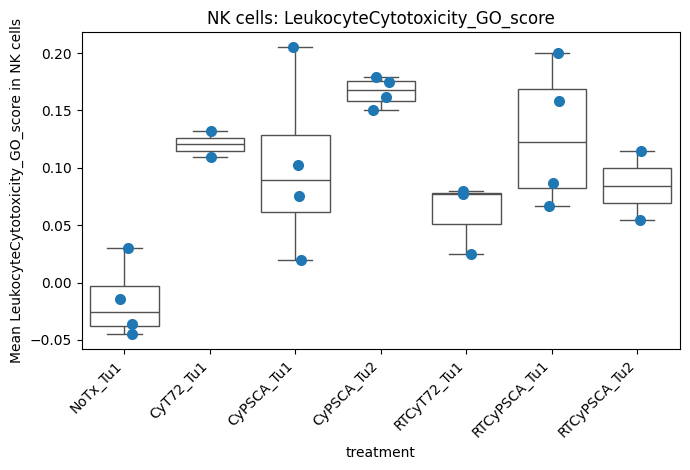

In [23]:
for score_col in nk_score_cols:
    metric = f"{score_col}_mean"

    plt.figure(figsize=(7, 4.8))

    sns.stripplot(
        data=nk_pathway_summary,
        x="treatment",
        y=metric,
        order=plot_order,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=nk_pathway_summary,
        x="treatment",
        y=metric,
        order=plot_order,
        showfliers=False,
        boxprops={"facecolor": "none"}
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean {score_col} in NK cells")
    plt.title(f"NK cells: {score_col}")
    plt.tight_layout()
    plt.show()

## NK cyt high look

In [24]:
nk_score_cols = [
    "GranzymeDeath_GO_score",
    "NK_MediatedImmunity_GO_score",
    "NK_Degranulation_GO_score",
    "LeukocyteCytotoxicity_GO_score",
]

nk_score_cols = [c for c in nk_score_cols if c in adata.obs.columns]

nk_mask = adata.obs["c2l_permissive"].astype(str).eq("NK")

for score_col in nk_score_cols:
    q75 = adata.obs.loc[nk_mask, score_col].quantile(0.75)
    q90 = adata.obs.loc[nk_mask, score_col].quantile(0.90)

    adata.obs[f"{score_col}_NK_q75_high"] = nk_mask & (adata.obs[score_col] >= q75)
    adata.obs[f"{score_col}_NK_q90_high"] = nk_mask & (adata.obs[score_col] >= q90)

    print(score_col)
    print(f"  NK-specific q75: {q75:.4f}")
    print(f"  NK-specific q90: {q90:.4f}")

GranzymeDeath_GO_score
  NK-specific q75: 0.5878
  NK-specific q90: 1.0343
NK_MediatedImmunity_GO_score
  NK-specific q75: 0.1019
  NK-specific q90: 0.2022
NK_Degranulation_GO_score
  NK-specific q75: 0.1423
  NK-specific q90: 0.3645
LeukocyteCytotoxicity_GO_score
  NK-specific q75: 0.1083
  NK-specific q90: 0.1997


In [25]:
nk_q75_summary = (
    adata.obs
    .loc[
        adata.obs["c2l_permissive"].astype(str).eq("NK")
        & adata.obs["treatment"].isin([
            "NoTx_Tu1",
            "CyT72_Tu1",
            "CyPSCA_Tu1",
            "CyPSCA_Tu2",
            "RTCyT72_Tu1",
            "RTCyPSCA_Tu1",
            "RTCyPSCA_Tu2",
        ])
    ]
    .groupby(["tissue", "condition", "tumor_loc", "replicate_num", "treatment"], observed=True)
    .agg(
        n_nk=("c2l_permissive", "size"),
        **{
            f"{score_col}_NK_q75_frac": (f"{score_col}_NK_q75_high", "mean")
            for score_col in nk_score_cols
        },
        **{
            f"{score_col}_NK_q90_frac": (f"{score_col}_NK_q90_high", "mean")
            for score_col in nk_score_cols
        }
    )
    .reset_index()
)

display(nk_q75_summary)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,GranzymeDeath_GO_score_NK_q75_frac,NK_MediatedImmunity_GO_score_NK_q75_frac,NK_Degranulation_GO_score_NK_q75_frac,LeukocyteCytotoxicity_GO_score_NK_q75_frac,GranzymeDeath_GO_score_NK_q90_frac,NK_MediatedImmunity_GO_score_NK_q90_frac,NK_Degranulation_GO_score_NK_q90_frac,LeukocyteCytotoxicity_GO_score_NK_q90_frac
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.122500,0.099167,0.188333,0.075417,0.025000,0.012083,0.055417,0.006667
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,0.427978,0.436288,0.423823,0.463989,0.152355,0.146814,0.186981,0.142659
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,0.769231,0.842105,0.668016,0.886640,0.368421,0.477733,0.340081,0.534413
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,0.277778,0.261905,0.321429,0.305556,0.071429,0.043651,0.103175,0.055556
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,266,0.563910,0.695489,0.567669,0.703008,0.240602,0.319549,0.293233,0.338346
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,61,0.672131,0.754098,0.655738,0.868852,0.229508,0.327869,0.327869,0.409836
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,3,0.666667,0.666667,0.333333,1.000000,0.000000,0.000000,0.000000,0.333333
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,2671,0.529390,0.619618,0.550730,0.653688,0.187196,0.295395,0.273306,0.344815
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,0.610390,0.571429,0.402597,0.519481,0.350649,0.220779,0.175325,0.110390
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,0.597059,0.588235,0.455882,0.600000,0.267647,0.205882,0.211765,0.211765


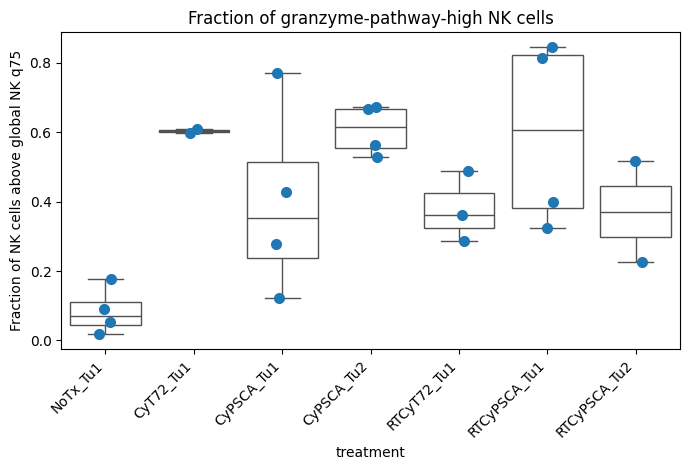

In [26]:
plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "CyPSCA_Tu2",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

metric = "GranzymeDeath_GO_score_NK_q75_frac"

plt.figure(figsize=(7, 4.8))

sns.stripplot(
    data=nk_q75_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    size=8,
    jitter=True
)

sns.boxplot(
    data=nk_q75_summary,
    x="treatment",
    y=metric,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Fraction of NK cells above global NK q75")
plt.title("Fraction of granzyme-pathway-high NK cells")
plt.tight_layout()
plt.show()

## NK stats

In [27]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd

def cliffs_delta_b_vs_a(a, b):
    """
    Positive value means group_b tends to be higher than group_a.
    """
    a = np.asarray(a)
    b = np.asarray(b)

    greater = 0
    less = 0

    for bi in b:
        greater += np.sum(bi > a)
        less += np.sum(bi < a)

    return (greater - less) / (len(a) * len(b))


def permutation_test_mean_diff(a, b, n_perm=10000, alternative="greater", seed=0):
    """
    Tests whether mean(b) - mean(a) is larger than expected by chance.
    alternative='greater' means group_b > group_a.
    """
    rng = np.random.default_rng(seed)

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    observed = np.mean(b) - np.mean(a)
    pooled = np.concatenate([a, b])
    n_a = len(a)

    perm_diffs = np.empty(n_perm)

    for i in range(n_perm):
        shuffled = rng.permutation(pooled)
        perm_a = shuffled[:n_a]
        perm_b = shuffled[n_a:]
        perm_diffs[i] = np.mean(perm_b) - np.mean(perm_a)

    if alternative == "greater":
        p = np.mean(perm_diffs >= observed)
    elif alternative == "less":
        p = np.mean(perm_diffs <= observed)
    else:
        p = np.mean(np.abs(perm_diffs) >= abs(observed))

    return observed, p

In [ ]:
# ── Outlier exclusion (edit this block) ───────────────────────────────────────
# List tissue sample IDs to drop from all stats and plots below.
# Set apply_exclusion = False to use all samples unchanged.
apply_exclusion = True

exclude_tissues = [
    "CyPSCA_1_3",
    "RTCyPSCA_1_2",
]
# ─────────────────────────────────────────────────────────────────────────────

if apply_exclusion and exclude_tissues:
    nk_pathway_summary_filt = nk_pathway_summary.loc[
        ~nk_pathway_summary["tissue"].isin(exclude_tissues)
    ].copy()
    nk_q75_summary_filt = nk_q75_summary.loc[
        ~nk_q75_summary["tissue"].isin(exclude_tissues)
    ].copy()
    print(f"Excluded: {exclude_tissues}")
    print(f"nk_pathway_summary: {len(nk_pathway_summary)} -> {len(nk_pathway_summary_filt)} rows")
    print(f"nk_q75_summary:     {len(nk_q75_summary)} -> {len(nk_q75_summary_filt)} rows")
else:
    nk_pathway_summary_filt = nk_pathway_summary.copy()
    nk_q75_summary_filt = nk_q75_summary.copy()
    print("No exclusion applied — using all samples.")

In [28]:
nk_score_metrics = [
    "GranzymeDeath_GO_score_mean",
    "NK_MediatedImmunity_GO_score_mean",
    "NK_Degranulation_GO_score_mean",
    "LeukocyteCytotoxicity_GO_score_mean",
]

nk_score_metrics = [m for m in nk_score_metrics if m in nk_pathway_summary_filt.columns]

group_a = "CyPSCA_Tu1"
group_b = "RTCyPSCA_Tu1"

nk_stats_rows = []

for metric in nk_score_metrics:
    a = nk_pathway_summary_filt.loc[
        nk_pathway_summary_filt["treatment"].eq(group_a),
        metric
    ].dropna()

    b = nk_pathway_summary_filt.loc[
        nk_pathway_summary_filt["treatment"].eq(group_b),
        metric
    ].dropna()

    # one-sided: RTCyPSCA_Tu1 > CyPSCA_Tu1
    if len(a) >= 2 and len(b) >= 2:
        mw_stat, mw_p_one_sided = mannwhitneyu(
            a,
            b,
            alternative="less"  # tests whether a < b
        )

        mw_stat_two, mw_p_two_sided = mannwhitneyu(
            a,
            b,
            alternative="two-sided"
        )

        mean_diff, perm_p_one_sided = permutation_test_mean_diff(
            a,
            b,
            n_perm=10000,
            alternative="greater",
            seed=42
        )

        delta = cliffs_delta_b_vs_a(a, b)

    else:
        mw_p_one_sided = np.nan
        mw_p_two_sided = np.nan
        perm_p_one_sided = np.nan
        mean_diff = np.nan
        delta = np.nan

    nk_stats_rows.append({
        "metric": metric,
        "group_a": group_a,
        "group_b": group_b,
        "n_group_a": len(a),
        "n_group_b": len(b),
        "mean_group_a": a.mean(),
        "mean_group_b": b.mean(),
        "median_group_a": a.median(),
        "median_group_b": b.median(),
        "mean_difference_b_minus_a": b.mean() - a.mean(),
        "median_difference_b_minus_a": b.median() - a.median(),
        "cliffs_delta_b_vs_a": delta,
        "mannwhitney_p_one_sided_b_greater": mw_p_one_sided,
        "mannwhitney_p_two_sided": mw_p_two_sided,
        "permutation_p_one_sided_b_greater": perm_p_one_sided,
    })

nk_pathway_stats_df = pd.DataFrame(nk_stats_rows)

display(nk_pathway_stats_df)

nk_pathway_stats_df.to_csv(
    outdir / "NK_curated_pathway_stats_CyPSCA_Tu1_vs_RTCyPSCA_Tu1.csv",
    index=False
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,mean_difference_b_minus_a,median_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_one_sided_b_greater,mannwhitney_p_two_sided,permutation_p_one_sided_b_greater
0,GranzymeDeath_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.475716,0.712187,0.452075,0.726127,0.236471,0.274052,0.375,0.242857,0.485714,0.1481
1,NK_MediatedImmunity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.087320,0.120989,0.073037,0.115823,0.033669,0.042786,0.250,0.342857,0.685714,0.2885
2,NK_Degranulation_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.101958,0.148044,0.082435,0.132522,0.046086,0.050087,0.125,0.442857,0.885714,0.3153
3,LeukocyteCytotoxicity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.100742,0.128201,0.089094,0.122807,0.027460,0.033713,0.125,0.442857,0.885714,0.3141


In [29]:
from statsmodels.stats.multitest import multipletests

nk_pathway_stats_df["fdr_mannwhitney_one_sided"] = multipletests(
    nk_pathway_stats_df["mannwhitney_p_one_sided_b_greater"].fillna(1.0),
    method="fdr_bh"
)[1]

nk_pathway_stats_df["fdr_permutation_one_sided"] = multipletests(
    nk_pathway_stats_df["permutation_p_one_sided_b_greater"].fillna(1.0),
    method="fdr_bh"
)[1]

display(
    nk_pathway_stats_df.sort_values("permutation_p_one_sided_b_greater")
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,median_group_a,median_group_b,mean_difference_b_minus_a,median_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_one_sided_b_greater,mannwhitney_p_two_sided,permutation_p_one_sided_b_greater,fdr_mannwhitney_one_sided,fdr_permutation_one_sided
0,GranzymeDeath_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.475716,0.712187,0.452075,0.726127,0.236471,0.274052,0.375,0.242857,0.485714,0.1481,0.442857,0.3153
1,NK_MediatedImmunity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.087320,0.120989,0.073037,0.115823,0.033669,0.042786,0.250,0.342857,0.685714,0.2885,0.442857,0.3153
3,LeukocyteCytotoxicity_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.100742,0.128201,0.089094,0.122807,0.027460,0.033713,0.125,0.442857,0.885714,0.3141,0.442857,0.3153
2,NK_Degranulation_GO_score_mean,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.101958,0.148044,0.082435,0.132522,0.046086,0.050087,0.125,0.442857,0.885714,0.3153,0.442857,0.3153


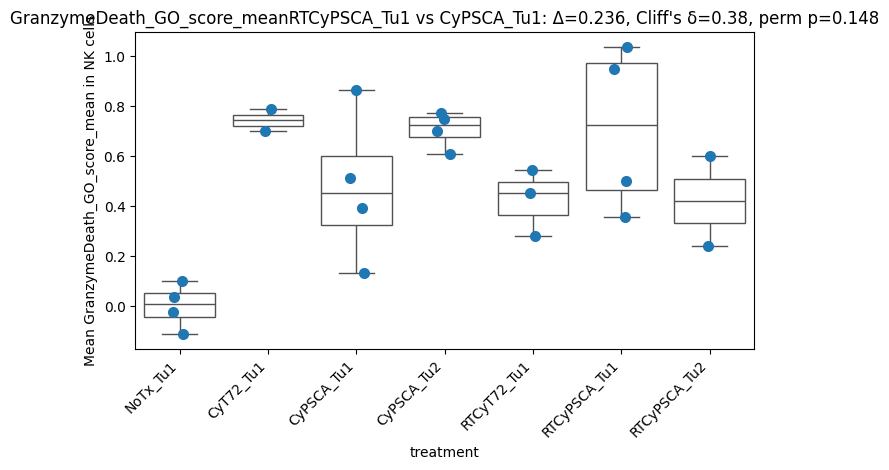

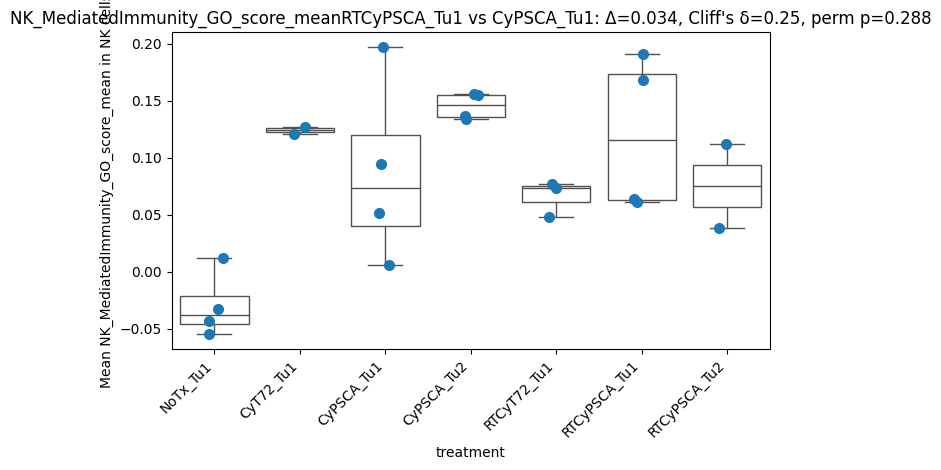

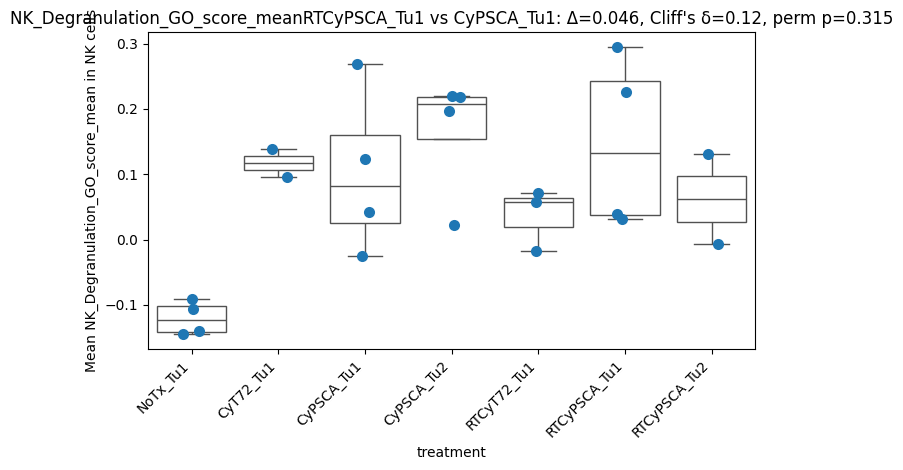

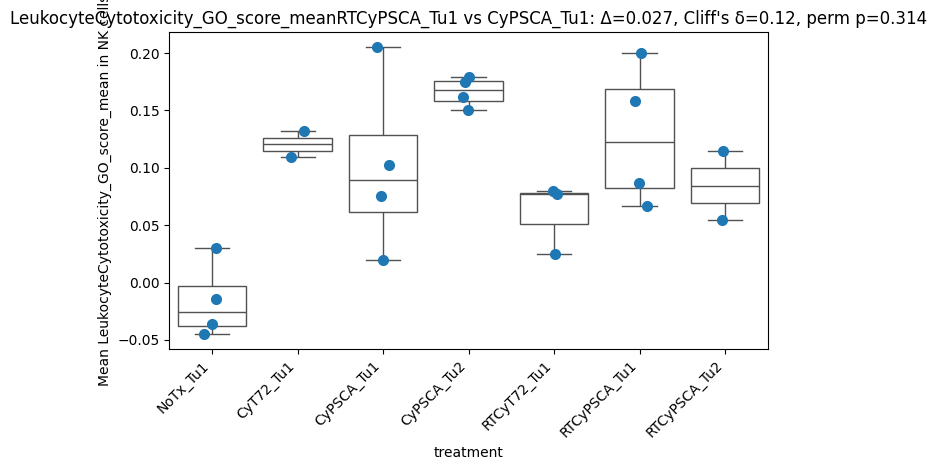

In [ ]:
plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "CyPSCA_Tu2",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

for metric in nk_score_metrics:
    stat_row = nk_pathway_stats_df.loc[
        nk_pathway_stats_df["metric"].eq(metric)
    ].iloc[0]

    p_perm = stat_row["permutation_p_one_sided_b_greater"]
    delta = stat_row["cliffs_delta_b_vs_a"]
    diff = stat_row["mean_difference_b_minus_a"]

    plt.figure(figsize=(7, 4.8))

    sns.stripplot(
        data=nk_pathway_summary_filt,
        x="treatment",
        y=metric,
        order=plot_order,
        size=8,
        jitter=True
    )

    sns.boxplot(
        data=nk_pathway_summary_filt,
        x="treatment",
        y=metric,
        order=plot_order,
        showfliers=False,
        boxprops={"facecolor": "none"}
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"Mean {metric} in NK cells")
    plt.title(
        f"{metric}"
        f"RTCyPSCA_Tu1 vs CyPSCA_Tu1: Δ={diff:.3f}, Cliff's δ={delta:.2f}, perm p={p_perm:.3f}"
    )
    plt.tight_layout()
    plt.show()

In [ ]:
nk_q75_metrics = [
    "GranzymeDeath_GO_score_NK_q75_frac",
    "NK_MediatedImmunity_GO_score_NK_q75_frac",
    "NK_Degranulation_GO_score_NK_q75_frac",
    "LeukocyteCytotoxicity_GO_score_NK_q75_frac",
]

nk_q75_metrics = [m for m in nk_q75_metrics if m in nk_q75_summary_filt.columns]

nk_q75_stats_rows = []

for metric in nk_q75_metrics:
    a = nk_q75_summary_filt.loc[
        nk_q75_summary_filt["treatment"].eq(group_a),
        metric
    ].dropna()

    b = nk_q75_summary_filt.loc[
        nk_q75_summary_filt["treatment"].eq(group_b),
        metric
    ].dropna()

    if len(a) >= 2 and len(b) >= 2:
        mw_stat, mw_p_one_sided = mannwhitneyu(
            a,
            b,
            alternative="less"
        )

        mw_stat_two, mw_p_two_sided = mannwhitneyu(
            a,
            b,
            alternative="two-sided"
        )

        mean_diff, perm_p_one_sided = permutation_test_mean_diff(
            a,
            b,
            n_perm=10000,
            alternative="greater",
            seed=42
        )

        delta = cliffs_delta_b_vs_a(a, b)

    else:
        mw_p_one_sided = np.nan
        mw_p_two_sided = np.nan
        perm_p_one_sided = np.nan
        mean_diff = np.nan
        delta = np.nan

    nk_q75_stats_rows.append({
        "metric": metric,
        "group_a": group_a,
        "group_b": group_b,
        "n_group_a": len(a),
        "n_group_b": len(b),
        "mean_group_a": a.mean(),
        "mean_group_b": b.mean(),
        "mean_difference_b_minus_a": b.mean() - a.mean(),
        "cliffs_delta_b_vs_a": delta,
        "mannwhitney_p_one_sided_b_greater": mw_p_one_sided,
        "mannwhitney_p_two_sided": mw_p_two_sided,
        "permutation_p_one_sided_b_greater": perm_p_one_sided,
    })

nk_q75_stats_df = pd.DataFrame(nk_q75_stats_rows)

display(nk_q75_stats_df)

nk_q75_stats_df.to_csv(
    outdir / "NK_curated_pathway_q75_fraction_stats_CyPSCA_Tu1_vs_RTCyPSCA_Tu1.csv",
    index=False
)

,metric,group_a,group_b,n_group_a,n_group_b,mean_group_a,mean_group_b,mean_difference_b_minus_a,cliffs_delta_b_vs_a,mannwhitney_p_one_sided_b_greater,mannwhitney_p_two_sided,permutation_p_one_sided_b_greater
0,GranzymeDeath_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.399372,0.595852,0.196481,0.50,0.171429,0.342857,0.1468
1,NK_MediatedImmunity_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.409866,0.601621,0.191755,0.50,0.171429,0.342857,0.1688
2,NK_Degranulation_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.400400,0.499397,0.098996,0.25,0.342857,0.685714,0.2675
3,LeukocyteCytotoxicity_GO_score_NK_q75_frac,CyPSCA_Tu1,RTCyPSCA_Tu1,4,4,0.432900,0.597172,0.164272,0.25,0.342857,0.685714,0.2615


In [ ]:
nk_pathway_summary_filt

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,GranzymeDeath_GO_score_mean,NK_MediatedImmunity_GO_score_mean,NK_Degranulation_GO_score_mean,LeukocyteCytotoxicity_GO_score_mean,GranzymeDeath_GO_score_median,NK_MediatedImmunity_GO_score_median,NK_Degranulation_GO_score_median,LeukocyteCytotoxicity_GO_score_median
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.131324,0.006018,-0.025377,0.019263,0.059944,-0.003610,-0.076602,0.012648
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,0.512101,0.094522,0.123287,0.102794,0.503609,0.088913,0.093432,0.098407
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,0.867393,0.197189,0.268339,0.205517,0.909168,0.196676,0.273653,0.209500
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,0.392048,0.051551,0.041583,0.075393,0.371186,0.047348,0.008159,0.069089
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,266,0.703352,0.155180,0.218598,0.161350,0.660890,0.153517,0.206368,0.163997
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,61,0.749445,0.155577,0.219631,0.179175,0.726829,0.150042,0.254235,0.173448
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,3,0.775263,0.133856,0.021954,0.174548,0.765258,0.140862,0.123384,0.160689
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,2671,0.607594,0.136670,0.197401,0.150487,0.624611,0.141815,0.178933,0.155953
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,0.787822,0.121001,0.096436,0.109364,0.794656,0.117704,0.092340,0.115429
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,0.700754,0.127281,0.139309,0.131841,0.681557,0.126503,0.107353,0.131190


In [ ]:
metric = "GranzymeDeath_GO_score_mean"

(
    nk_pathway_summary_filt[
        ["tissue", "condition", "tumor_loc", "replicate_num", "treatment", "n_nk", metric]
    ]
    .sort_values(["treatment", metric])
)

,tissue,condition,tumor_loc,replicate_num,treatment,n_nk,GranzymeDeath_GO_score_mean
0,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,2400,0.131324
3,CyPSCA_1_4,CyPSCA,1,4,CyPSCA_Tu1,252,0.392048
1,CyPSCA_1_2,CyPSCA,1,2,CyPSCA_Tu1,722,0.512101
2,CyPSCA_1_3,CyPSCA,1,3,CyPSCA_Tu1,247,0.867393
7,CyPSCA_2_4,CyPSCA,2,4,CyPSCA_Tu2,2671,0.607594
4,CyPSCA_2_1,CyPSCA,2,1,CyPSCA_Tu2,266,0.703352
5,CyPSCA_2_2,CyPSCA,2,2,CyPSCA_Tu2,61,0.749445
6,CyPSCA_2_3,CyPSCA,2,3,CyPSCA_Tu2,3,0.775263
9,CyT72_1_4,CyT72,1,4,CyT72_Tu1,340,0.700754
8,CyT72_1_2,CyT72,1,2,CyT72_Tu1,154,0.787822


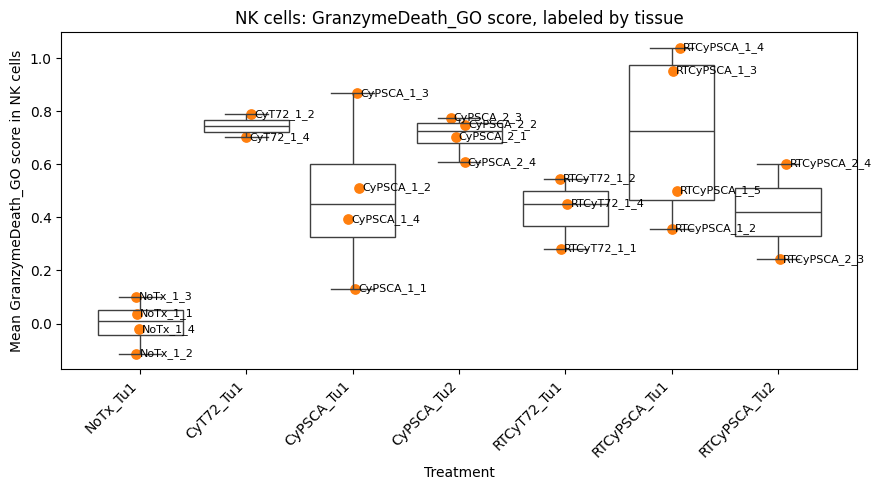

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

metric = "GranzymeDeath_GO_score_mean"

plot_order = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyPSCA_Tu1",
    "CyPSCA_Tu2",
    "RTCyT72_Tu1",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

plot_df = nk_pathway_summary_filt.loc[
    nk_pathway_summary_filt["treatment"].isin(plot_order)
].copy()

# Manual jitter so labels line up with the points
rng = np.random.default_rng(7)
x_map = {treatment: i for i, treatment in enumerate(plot_order)}
plot_df["x_jitter"] = (
    plot_df["treatment"].map(x_map).astype(float)
    + rng.uniform(-0.08, 0.08, size=plot_df.shape[0])
)

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=plot_df,
    x="treatment",
    y=metric,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.scatter(
    plot_df["x_jitter"],
    plot_df[metric],
    s=45
)

for _, row in plot_df.iterrows():
    plt.text(
        row["x_jitter"] + 0.03,
        row[metric],
        row["tissue"],
        fontsize=8,
        va="center"
    )

plt.xticks(
    ticks=range(len(plot_order)),
    labels=plot_order,
    rotation=45,
    ha="right"
)

plt.ylabel("Mean GranzymeDeath_GO score in NK cells")
plt.xlabel("Treatment")
plt.title("NK cells: GranzymeDeath_GO score, labeled by tissue")
plt.tight_layout()
plt.show()

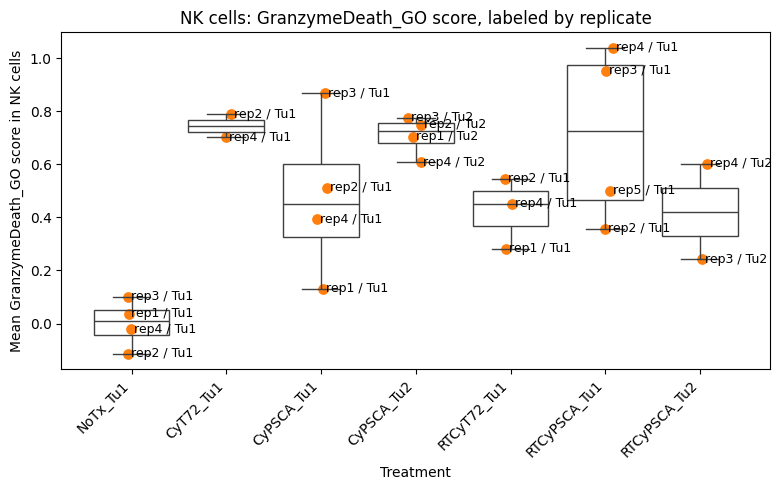

In [ ]:
metric = "GranzymeDeath_GO_score_mean"

plot_df = nk_pathway_summary_filt.loc[
    nk_pathway_summary_filt["treatment"].isin(plot_order)
].copy()

plot_df["label"] = (
    "rep" + plot_df["replicate_num"].astype(str)
    + " / Tu" + plot_df["tumor_loc"].astype(str)
)

rng = np.random.default_rng(7)
x_map = {treatment: i for i, treatment in enumerate(plot_order)}
plot_df["x_jitter"] = (
    plot_df["treatment"].map(x_map).astype(float)
    + rng.uniform(-0.08, 0.08, size=plot_df.shape[0])
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=plot_df,
    x="treatment",
    y=metric,
    order=plot_order,
    showfliers=False,
    boxprops={"facecolor": "none"}
)

plt.scatter(
    plot_df["x_jitter"],
    plot_df[metric],
    s=45
)

for _, row in plot_df.iterrows():
    plt.text(
        row["x_jitter"] + 0.03,
        row[metric],
        row["label"],
        fontsize=9,
        va="center"
    )

plt.xticks(
    ticks=range(len(plot_order)),
    labels=plot_order,
    rotation=45,
    ha="right"
)

plt.ylabel("Mean GranzymeDeath_GO score in NK cells")
plt.xlabel("Treatment")
plt.title("NK cells: GranzymeDeath_GO score, labeled by replicate")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

metric = "GranzymeDeath_GO_score_mean"

plot_df = nk_pathway_summary_filt.loc[
    nk_pathway_summary_filt["treatment"].isin(plot_order)
].copy()

fig = px.strip(
    plot_df,
    x="treatment",
    y=metric,
    category_orders={"treatment": plot_order},
    hover_data=[
        "tissue",
        "condition",
        "tumor_loc",
        "replicate_num",
        "treatment",
        "n_nk",
        metric,
    ],
    title="NK cells: GranzymeDeath_GO score"
)

fig.update_traces(jitter=0.25, marker_size=9)
fig.show()